# Correção Gama

Aplicar correção gama para ajustar o brilho de uma imagem monocromática A de entrada e gerar uma imagem monocromática B de saída.

A transformação é realizada em três etapas:
1. Converter as intensidades dos pixels de [0, 255] para [0, 1]
2. Aplicar a equação $B = A^{(1/\gamma)}$
3. Converter os valores resultantes de volta para [0, 255]

**Restrição:** Usar apenas OpenCV para carregar e salvar imagens. Todas as operações devem ser implementadas manualmente.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Função de Correção Gama (Implementação Manual)

In [2]:
def correcao_gama(img, gamma):
    """
    Aplica correção gama manualmente.
    
    Parâmetros:
    - img: imagem monocromática de entrada [0, 255]
    - gamma: valor de gama (γ > 1 escurece, γ < 1 clareia)
    
    Retorna:
    - imagem com correção gama aplicada
    """
    # (i) Converter de [0, 255] para [0, 1]
    img_normalizada = img.astype(np.float64) / 255.0
    
    # (ii) Aplicar equação B = A^(1/γ)
    img_corrigida = np.power(img_normalizada, 1.0 / gamma)
    
    # (iii) Converter de volta para [0, 255]
    img_resultado = np.clip(img_corrigida * 255.0, 0, 255).astype(np.uint8)
    
    return img_resultado

## Carregar Imagem de Entrada

In [3]:
# Carregar imagem2 usando OpenCV (escala de cinza)
imagem2 = cv2.imread('imagem2.jpg', cv2.IMREAD_GRAYSCALE)

if imagem2 is None:
    raise ValueError("Erro ao carregar imagem2.jpg!")

print(f"Imagem2 carregada: {imagem2.shape}")

Imagem2 carregada: (3168, 4752)


## Aplicar Correção Gama com Diferentes Valores de γ

In [4]:
# Valores de gamma para teste
gammas = [0.25, 0.5, 1.0, 1.5, 2.0, 3.0]

# Aplicar correção gama para cada valor
resultados_gama = {}
for gamma in gammas:
    resultados_gama[gamma] = correcao_gama(imagem2, gamma)
    cv2.imwrite(f'imagem2_gama_{gamma}.jpg', resultados_gama[gamma])
    print(f"Gamma = {gamma}: imagem salva")

print("\nCorreção gama concluída!")
print("Arquivos salvos:")
for gamma in gammas:
    print(f"  - imagem2_gama_{gamma}.jpg")

Gamma = 0.25: imagem salva
Gamma = 0.5: imagem salva
Gamma = 1.0: imagem salva
Gamma = 1.5: imagem salva
Gamma = 2.0: imagem salva
Gamma = 3.0: imagem salva

Correção gama concluída!
Arquivos salvos:
  - imagem2_gama_0.25.jpg
  - imagem2_gama_0.5.jpg
  - imagem2_gama_1.0.jpg
  - imagem2_gama_1.5.jpg
  - imagem2_gama_2.0.jpg
  - imagem2_gama_3.0.jpg


## Visualização dos Resultados

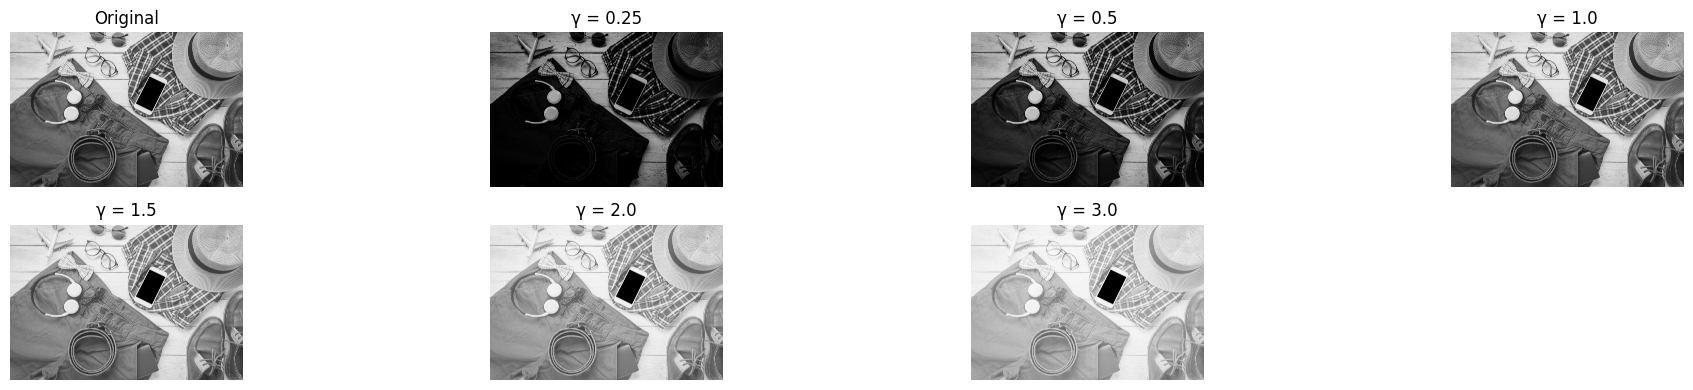

In [5]:
# Visualizar resultados da correção gama
plt.figure(figsize=(20, 4))

# Imagem original
plt.subplot(2, 4, 1)
plt.imshow(imagem2, cmap='gray')
plt.title('Original')
plt.axis('off')

# Mostrar resultados para cada gamma
for i, gamma in enumerate(gammas):
    plt.subplot(2, 4, i+2)
    plt.imshow(resultados_gama[gamma], cmap='gray')
    plt.title(f'γ = {gamma}')
    plt.axis('off')

plt.tight_layout()
plt.savefig('comparativo_gama.png', dpi=150)
plt.show()

## Efeitos da Correção Gama

In [6]:
print("Efeitos da correção gama:")
print("  γ < 1 : clareia a imagem (realça regiões escuras)")
print("  γ = 1 : sem alteração (imagem original)")
print("  γ > 1 : escurece a imagem (realça regiões claras)")
print()
print("Exemplos:")
print("  γ = 0.25: forte clareamento")
print("  γ = 0.5:  clareamento moderado")
print("  γ = 1.5:  leve escurecimento")
print("  γ = 2.0:  escurecimento moderado")
print("  γ = 3.0:  forte escurecimento")

Efeitos da correção gama:
  γ < 1 : clareia a imagem (realça regiões escuras)
  γ = 1 : sem alteração (imagem original)
  γ > 1 : escurece a imagem (realça regiões claras)

Exemplos:
  γ = 0.25: forte clareamento
  γ = 0.5:  clareamento moderado
  γ = 1.5:  leve escurecimento
  γ = 2.0:  escurecimento moderado
  γ = 3.0:  forte escurecimento
